# Sound Processing Lab - Part #2

In this notebook you'll learn:
- How to implement different types of frequency filters
- How to implement noise reduction
- How to apply Fourier Transform (back and forth)
- How to implement Mel-Frequency Cepstral (MFCCs)

In [ ]:
# Imports and configuration
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display
import sounddevice as sd
from scipy.signal import butter, filtfilt, wiener
import noisereduce as nr
import soundfile as sf

# Let's load an MP3 for the lab


In [ ]:
# Path to your audio file: change this to the MP3 you downloaded
audio_path = '..\\sounds\\dog\\dog_bark_2.mp3'  # <-- REPLACE with your file path (mp3 is supported)

if not os.path.exists(audio_path):
    print(f'File not found: {audio_path} — please update the path and re-run this cell')
else:
    ext = os.path.splitext(audio_path)[1].lower()
    y = None
    sr = None
    # If pydub is available, use it to load reliably (handles mp3 via ffmpeg)
    try:
        y, sr = librosa.load(audio_path, sr=None, mono=False)
    except Exception as e:
        print('pydub not available or failed to read the file. Error:', e)

    # librosa returns shape (n,) for mono or (channels, n) for stereo when mono=False
    if y is None:
        print('Failed to load audio.')
    else:
        if hasattr(y, 'ndim') and y.ndim == 2:
            n_channels = y.shape[0]
            n_samples = y.shape[1]
        else:
            n_channels = 1
            n_samples = y.shape[0]
        duration_sec = n_samples / float(sr)

        print('Loaded:', audio_path)
        print('Sampling rate (Hz):', sr)
        print('Channels:', n_channels)
        print('Total samples:', n_samples)
        print(f'Duration (s): {duration_sec:.3f}')
        print(f'Dataset size:  {y.size} - Dataset shape: {y.shape}')  # total samples and shape (channels, samples) or (samples,)

        # create a mono version for plotting/analysis (average channels if stereo)
        if n_channels > 1:
            y_mono = librosa.to_mono(y)
        else:
            y_mono = y

        # keep these variables in the notebook namespace for later cells
        globals()['y'] = y
        globals()['y_mono'] = y_mono
        globals()['sr'] = sr
        globals()['audio_path'] = audio_path

        # Play audio inline
        display(Audio(y_mono, rate=sr))

# Filtering a sound
Let's implement low-band, pass-band and high-band filters.

In [ ]:
def low_pass_filter(audio_signal, cutoff_freq, sample_rate, order=5):
    """Allows frequencies BELOW the cutoff to pass, cutting off highs."""
    nyquist = 0.5 * sample_rate
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, audio_signal)

def high_pass_filter(audio_signal, cutoff_freq, sample_rate, order=5):
    """Allows frequencies ABOVE the cutoff to pass, cutting off lows."""
    nyquist = 0.5 * sample_rate
    normal_cutoff = cutoff_freq / nyquist
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    return filtfilt(b, a, audio_signal)

def band_pass_filter(audio_signal, low_cutoff, high_cutoff, sample_rate, order=5):
    """Allows only frequencies WITHIN the low and high range to pass."""
    nyquist = 0.5 * sample_rate
    low = low_cutoff / nyquist
    high = high_cutoff / nyquist
    b, a = butter(order, [low, high], btype='band', analog=False)
    return filtfilt(b, a, audio_signal)

# ==========================================
# 1. Keep only bass/lows (under 300 Hz)
bass_only = low_pass_filter(y_mono, cutoff_freq=300, sample_rate=sr)

# 2. Keep only treble/highs (above 4000 Hz)
treble_only = high_pass_filter(y_mono, cutoff_freq=4000, sample_rate=sr)

# 3. Keep only radio/voice mid-range (between 300 Hz and 3000 Hz)
voice_only = band_pass_filter(y_mono, low_cutoff=300, high_cutoff=3000, sample_rate=sr)


# =====================================================================
# Setup time axis for plotting (First 50 ms)
# =====================================================================
duration_to_plot = 0.05 
samples_to_plot = int(sr * duration_to_plot)
time_axis = np.linspace(0, duration_to_plot, samples_to_plot, endpoint=False) * 1000 

# =====================================================================
# 1. Original Audio
# =====================================================================
plt.figure(figsize=(10, 2.5))
plt.plot(time_axis, y_mono[:samples_to_plot], color='black', linewidth=1)
plt.title('Original Unfiltered Audio')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

print("Listen to Original Audio:")
display(Audio(y_mono, rate=sr))

# =====================================================================
# 2. Low-Pass Filtered (Bass Only)
# =====================================================================
plt.figure(figsize=(10, 2.5))
plt.plot(time_axis, bass_only[:samples_to_plot], color='blue', linewidth=1)
plt.title('Low-Pass Filtered (Bass Only < 300 Hz)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

print("Listen to Low-Pass (Muffled/Bass heavy):")
display(Audio(bass_only, rate=sr))

# =====================================================================
# 3. High-Pass Filtered (Treble Only)
# =====================================================================
plt.figure(figsize=(10, 2.5))
plt.plot(time_axis, treble_only[:samples_to_plot], color='red', linewidth=1)
plt.title('High-Pass Filtered (Treble Only > 4000 Hz)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

print("Listen to High-Pass (Hissing/Tinny):")
display(Audio(treble_only, rate=sr))

# =====================================================================
# 4. Band-Pass Filtered (Mid-Range/Voice)
# =====================================================================
plt.figure(figsize=(10, 2.5))
plt.plot(time_axis, voice_only[:samples_to_plot], color='green', linewidth=1)
plt.title('Band-Pass Filtered (Mid-Range 300 Hz - 3000 Hz)')
plt.xlabel('Time (ms)')
plt.ylabel('Amplitude')
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

print("Listen to Band-Pass (Radio/Telephone effect):")
display(Audio(voice_only, rate=sr))


# What if we wanted to instead clean up the noise present in a wave?
The noise filtering implementation with Python is quite simple, as follows:

In [ ]:
# 1. Reduce noise (One-liner equivalent to rmnoise)
# stationary=True works perfectly for constant background hiss/hum
audio_cleaned = nr.reduce_noise(y=y_mono, sr=sr, stationary=True)

# 2. Save the clean file
sf.write('..\sounds\cleaned_audio.wav', audio_cleaned, sr)

# 3. Play the cleaned audio
display(Audio(audio_cleaned, rate=sr))

In [ ]:
# Another implementation, this time with native Wiener filter (not as good as noisereduce for this type of noise, but included for demonstration)
# This filter uses scipy library instead

# 1. Apply the Wiener filter to the mono audio signal
# mysize controls the local neighborhood size (must be an odd integer) - larger values will smooth more but may also blur the signal
audio_cleaned_wiener = wiener(y_mono, mysize=11)

# 2. Save the clean file
sf.write('..\sounds\cleaned_audio_wiener.wav', audio_cleaned_wiener, sr)

# 3. Play the cleaned audio
display(Audio(audio_cleaned_wiener, rate=sr))

# Fourier Transform Implementation
This part of the lab will consist of 3 stages:
<ol type="a">
    <li> First we will generate a signal adjusting some parameters and then add white noise to it </li>
    <li> Then we will apply Fourier Transform to break it apart into sub-sets of smaller and much simpler sub-functions of the signal </li>
    <li> Finally, we will re-build through a sum, the original signal again; prooving Fourier is reversible </li>
</ol>

In [ ]:
# ----------------------------------------------------------------------------------------
# A. First we will generate a signal adjusting some parameters and adding noise to it, so we can see how the filters work in the next cells
# ----------------------------------------------------------------------------------------
# 1. Setup global parameters
sampling_rate = 22050  # 22050 samples per second (it's also governed by the Nyquist-Shannon sampling theorem)
duration = 3.0        # 3 seconds of audio
time = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)

# 2. Define individual "ingredients" (Tune amplitudes and frequencies here!)
wave_1 = 3.0 * np.sin(2 * np.pi * 30 * time)    # 30 Hz wave, Amplitude = 3.0
wave_2 = 1.5 * np.sin(2 * np.pi * 70 * time)   # 70 Hz wave, Amplitude = 1.5
wave_3 = 0.8 * np.sin(2 * np.pi * 150 * time)   # 150 Hz wave, Amplitude = 0.8

# 3. Combine them into a single complex mystery signal
clean_signal = wave_1 + wave_2 + wave_3

# 4. Generate White Gaussian Noise and pollute the signal
# Mean = 0, Standard Deviation = 0.15 (enough to visibly distort the waves)
np.random.seed(42) # Ensures identical random noise every run
noise = np.random.normal(0, 0.15, len(time))
noisy_signal = clean_signal + noise

# 5. Plot the final combined signal
plt.figure(figsize=(12, 4))
plt.plot(time, noisy_signal, color='black', linewidth=1.5)
plt.title('The Combined Mystery Signal (Time Domain)', fontsize=14)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.grid(True, linestyle='--')
plt.xlim(0, 0.5)  # Zoom into the first 0.5 seconds for visual clarity
plt.tight_layout()
plt.show()

display(Audio(noisy_signal, rate=sampling_rate))

In [ ]:
# ----------------------------------------------------------------------------------------
# B. Then we will apply Fourier Transform to break it apart into sub-sets of smaller and much simpler sub-functions of the signal
# ----------------------------------------------------------------------------------------
# 1. Compute the Fourier Transform of the NOISY signal
fft_raw = np.fft.rfft(noisy_signal)
frequencies = np.fft.rfftfreq(len(noisy_signal), d=1/sampling_rate)
magnitudes = np.abs(fft_raw) * 2 / len(noisy_signal)

# 2. FILTERING STEP: Only keep frequencies with a strong amplitude peak
# Random noise stays low, our intentional frequencies spike high
amplitude_threshold = 0.05
peak_indices = np.where(magnitudes > amplitude_threshold)[0]

print(f"Fourier analysis complete. Filtered out the background noise floor!")
print(f"Found {len(peak_indices)} frequencies surviving the threshold filter:\n")

# 3. Plot the isolated, cleaned-up components
fig, axs = plt.subplots(len(peak_indices), 1, figsize=(12, 2.5 * len(peak_indices)), sharex=True)
denoised_pieces = []

for i, idx in enumerate(peak_indices):
    freq = frequencies[idx]
    amp = magnitudes[idx]
    
    # Re-synthesize the clean individual component
    clean_sub_wave = amp * np.sin(2 * np.pi * freq * time)
    denoised_pieces.append(clean_sub_wave)
    
    print(f" -> Recovered Component {i+1}: {freq:.1f} Hz | True Amplitude: {amp:.2f}")
    
    # Plotting
    axs[i].plot(time, clean_sub_wave, color='purple', linewidth=1.5)
    axs[i].set_title(f'Recovered Component {i+1}: {freq:.1f} Hz (Noise Stripped Away)', fontsize=11)
    axs[i].set_ylabel('Amplitude')
    axs[i].grid(True, linestyle='--')

plt.xlabel('Time (seconds)', fontsize=12)
plt.xlim(0, 0.02)
plt.tight_layout()
plt.show()

In [ ]:
# ----------------------------------------------------------------------------------------
# C. Finally, we will re-build through a sum, the original signal again; prooving Fourier is reversible
# ----------------------------------------------------------------------------------------
# 1. Reconstruct by summing only the clean components
denoised_signal = np.sum(denoised_pieces, axis=0)

# 2. Plot the Before (Noisy) vs After (Denoised)
plt.figure(figsize=(12, 5))
plt.plot(time, noisy_signal, color='red', alpha=0.4, label='1. Polluted Input Signal (With Noise)')
plt.plot(time, denoised_signal, color='green', linewidth=2, label='2. Denoised Output (Fourier Reconstructed)')

plt.title('Signal Denoising: Before vs After Fourier Thresholding', fontsize=14)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.legend(loc='upper right', fontsize=11)
plt.grid(True, linestyle='--')
plt.xlim(0, 0.02)
plt.tight_layout()
plt.show()

print("Listen to the beautifully filtered, denoised result:")
display(Audio(denoised_signal, rate=sampling_rate))

# How to implement Mel-Frequency Cepstral Coefficients (MFCCs)

Standard Fourier uses linear spacing, but human ears are much more sensitive to changes in low frequencies than high frequencies. The Mel Scale warps the frequency axis so that equal distances on the scale sound like equal pitches to us.

Mel-Frequency Cepstral Coefficients (MFCCs) compress the Mel Spectrogram even further. They strip away the specific pitch details and leave behind the "envelope" or shape of the sound (timbre). This is the exact representation used by speech recognition systems and audio classification AIs to identify what vowel is being spoken or which instrument is playing.


This part of the lab will be split in 2 stages:
<ol type="a">
    <li> First we will build the Mel Spectogram using our own voices (in Human Hearing Scale, of course) </li>
    <li> Then we will apply apply MFCC to find the AI Speech Blueprint </li>
</ol>

In [ ]:
# ----------------------------------------------------------------------------------------
# A. First we will build the Mel Spectogram using our own voices (in Human Hearing Scale, of course)
# ----------------------------------------------------------------------------------------
# 1. Setup recording parameters
# 22050 Hz is perfect for human speech and keeps processing fast
# A common practical standard is doubling sampling rate to the highest frequency captured in the sample, following Nyquist.
sampling_rate_voice = 22050  
duration = 5.0         # 5 seconds is ideal for saying a short phrase or vowel

print("🎤 RECORDING STARTED... Speak into your microphone now!")
# Capture the audio (channels=1 for mono)
raw_recording = sd.rec(int(duration * sampling_rate_voice), samplerate=sampling_rate_voice, channels=1, dtype='float32')
sd.wait()  # Wait until the 3 seconds are up
print("🛑 RECORDING STOPPED.")

# CRITICAL STEP: sounddevice records as a 2D array (samples, channels). 
# Librosa requires a flat 1D array. We use .flatten() to fix this.
voice_signal = raw_recording.flatten()

# 2. Plot the raw time-domain waveform
plt.figure(figsize=(12, 3))
time_axis = np.linspace(0, duration, len(voice_signal))
plt.plot(time_axis, voice_signal, color='darkblue', linewidth=1)
plt.title('Your Raw Voice Waveform (Time Domain)', fontsize=14)
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('Amplitude', fontsize=12)
plt.grid(True, linestyle='--')
plt.tight_layout()
plt.show()

# 3. Audio player to verify the recording
print("Listen back to your recording:")
display(Audio(voice_signal, rate=sampling_rate_voice))

try:
    # 1. Compute the Mel Spectrogram
    # n_mels=128 creates 128 psychological frequency bands (filterbanks)
    mel_spectrogram = librosa.feature.melspectrogram(
        y=voice_signal, 
        sr=sampling_rate_voice, 
        n_mels=128, 
        fmax=sampling_rate_voice/2
    )

    # 2. Convert power to decibels (logarithmic amplitude)
    mel_spectrogram_db = librosa.power_to_db(mel_spectrogram, ref=np.max)

    # 3. Plot the Mel Spectrogram
    plt.figure(figsize=(12, 5))
    librosa.display.specshow(
        mel_spectrogram_db, 
        sr=sampling_rate_voice, 
        x_axis='time', 
        y_axis='mel', # Warps the Y-axis to the Mel Scale!
        fmax=sampling_rate_voice/2, 
        cmap='viridis'
    )

    plt.title('Mel Spectrogram (Perceptual Frequency Scale)', fontsize=14)
    plt.colorbar(format='%+2.0f dB')
    plt.xlabel('Time (seconds)', fontsize=12)
    plt.ylabel('Frequency (Mel Scale)', fontsize=12)
    plt.tight_layout()
    plt.show()

except NameError:
    print("Please run your Signal Generator cell first to define 'voice_signal' and 'sampling_rate_voice'.")

The Heatmap above - The Colors = Loudness (Decibels): The brightness of the color represents the energy or volume of a specific frequency at a specific millisecond.
* Bright colors (Yellow/Orange) mean a frequency is bursting with high energy (loud).
* Dark colors (Blue/Purple) mean that frequency is silent or incredibly faint.

In [ ]:
# ----------------------------------------------------------------------------------------
# B. Then we will apply apply MFCC to find the AI Speech Blueprint
# ----------------------------------------------------------------------------------------
# 1. Extract MFCCs from the audio signal
# n_mfcc=13 or 20 is standard for speech and audio classification
mfccs = librosa.feature.mfcc(y=voice_signal, sr=sampling_rate_voice, n_mfcc=13)

# 2. Plot the MFCCs
plt.figure(figsize=(12, 5))
librosa.display.specshow(
    mfccs, 
    sr=sampling_rate_voice, 
    x_axis='time'
)

plt.title('Mel-Frequency Cepstral Coefficients (MFCCs)', fontsize=14)
plt.colorbar()
plt.xlabel('Time (seconds)', fontsize=12)
plt.ylabel('MFCC Coefficients / Coefficients Index', fontsize=12)
plt.tight_layout()
plt.show()

# Print the matrix shape so students can see the data structure
print(f"MFCC Data Matrix Shape: {mfccs.shape}")
print(f" -> {mfccs.shape[0]} unique coefficients (features) tracking the sound's timbre.")
print(f" -> {mfccs.shape[1]} time windows (frames) captured across the duration.")
print("CONGRATULATIONS FOR YOUR FEATURE EXTRACTION, you have extracted the AI Speech Blueprint from your own voice recording! 🎉")

The Heatmap above:
* The X-Axis (Horizontal) = Time: Just like the spectrogram, this moves chronologically from left to right through the 3-second recording.  
* The Y-Axis (Vertical) = Coefficient Index (0 to 12): Crucial point for students: These numbers are not Hertz or Mels. They are feature vectors. Think of each number as a specific physical slider on a giant vocal synthesizer.  
* The Colors = Feature Intensity: Because MFCCs can have both positive and negative values, we use a divergent color map (like coolwarm).  
    * Deep Reds/Oranges: Strong positive correlation for that specific vocal texture descriptor.  
    * Deep Blues: Strong negative correlation.  
    * White/Gray: Neutral or silent.  

# Bonus track of the chapter

Since we will keep working with your own voice fingerprints later, why not saving the vectors that make your voice, well... Actually yours...

In [ ]:
np.save('..\\mfcc\\my_voice_features.npy', mfccs)
print("✅ MFCC features successfully persisted to 'my_voice_features.npy'!")

# =====================================================================
# NEXT TIME YOU NEED THEM: How to import your saved features
# =====================================================================
# # Inside the next notebook or whereever you need them, they just run:
# loaded_mfccs = np.load('..\\mfcc\\my_voice_features.npy')
# print(f"Successfully reloaded feature matrix with shape: {loaded_mfccs.shape}")

## What have we learned?

Let's discuss in class.



Got more time and want to continue playing? Cool!
* Here's a cool YouTube video on background noise removal with Fourier Transform for later: https://www.youtube.com/watch?v=WH9XShX5OPY
* Continue playing with adjusting parameters of the signal generator, change frequencies, duration, etc. Have fun!
* Record your own voice and filter it, apply Fourier Transform and MFCC
* Remember key facts:
    * Noise is just another "sub-function" added to the original signal.
    * We can simulate noise with a pseudo-random signal; which is, in escence, white noise with a gaussian distribution.


## A bit more theory to explore on Fourier and signal filtering
**1. The Speed Rule: Sampling Frequency vs. Highest Frequency**

This is governed by the Nyquist-Shannon Sampling Theorem. It dictates the absolute mathematical relationship between your sampling rate ($f_s$) and the highest frequency ($f_{max}$) present in the signal.
<br>The Rule:$$f_s > 2 \cdot f_{max}$$

* **The Concept:** To capture a wave accurately, you must sample it at least twice per cycle (once for the peak, once for the trough). If you sample any slower, the high frequencies wrap around and masquerade as fake low frequencies. This distortion is called aliasing.

* **Why our example in class works:** Human speech rarely carries meaningful information above 8,000 Hz or 10,000 Hz. By using $f_s = 22,050\text{ Hz}$ for the voice recording, your Nyquist limit is $11,025\text{ Hz}$, easily capturing the full vocal spectrum without aliasing.
<br><br>

**2. The Length Rule: Sample Duration vs. Precision**

* Your sample length in seconds ($T$) dictates your Frequency Resolution ($\Delta f$), which is the width of the frequency bins in your final plot.
The Rule:$$\Delta f = \frac{1}{T}$$

**The Concept:** Time and frequency have an inverse relationship. If you want to look closely at frequencies, you need to watch the signal for a longer period of time.
**Why our exmple in class works:** With a duration of $T = 1.5\text{ seconds}$, your frequency resolution is $\Delta f = \frac{1}{1.5} \approx 0.67\text{ Hz}$. This means your Fourier Transform can distinguish between a 220 Hz note and a 221 Hz note. If your sample was only 0.05 seconds long, your resolution would drop to 20 Hz, making your frequency plots look incredibly blurry and imprecise.


### Some more insightful concepts
There are two hidden phenomena that we always run into when applying Fourier transforms to real-world data.  
But first: There're several types of Fourier transformations, depending on the type of scenario we need to implement it:
<center>

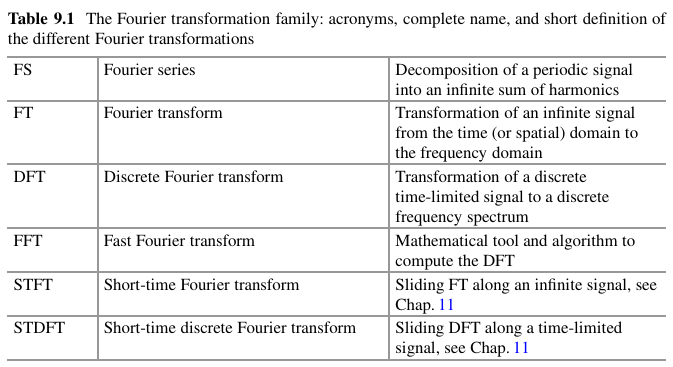
</center>

**Phenomena #1: Spectral Leakage (Why we need "windowing"):**  
The Fourier Transform mathematically assumes that your 1.5-second audio snippet repeats perfectly into infinity. However, if the wave doesn't start and end exactly at zero amplitude, cutting it creates harsh, artificial edges at the boundaries.

In the frequency domain, these sharp cuts look like high-frequency noise, causing energy to "leak" into neighboring bins and making sharp peaks look like wide pyramids.

**The Fix:** In real applications, we multiply the audio signal by a smooth curve called a Window Function (like a Hann or Hamming window) that gently tapers the edges of the audio down to zero before running the FFT.  

**Phenomena #2: The ilusion of time (stationary):**  
A standard Fourier Transform completely destroys time information. It tells you exactly what frequencies are in the sample, but it cannot tell you *when they happened*.

If you record yourself saying "No" in the first second and "Yes" in the second second, a standard FFT will mix them completely together, showing the frequencies of both vowels at the same time.

**The Connection:** This is exactly why we use the Short-Time Fourier Transform (STFT) for speech, which cuts the audio into tiny, overlapping 20-millisecond windows and runs an FFT on each window sequentially. This is the exact math happening under the hood of the Mel Spectrogram you built in the previous section!

Let's see a practical example below.

In [ ]:
# 1. Setup parameters
sampling_rate = 1000  
duration = 1.0        
time = np.linspace(0, duration, int(sampling_rate * duration), endpoint=False)

# 2. Create a frequency that does NOT fit perfectly into a 1-second window (10.5 cycles)
# This guarantees that the start and end of the sample will not meet at zero amplitude
frequency = 10.5  
signal = np.sin(2 * np.pi * frequency * time)

# 3. Apply a Hann Window to create a secondary, tapered version of the signal
hann_window = np.hanning(len(signal))
windowed_signal = signal * hann_window

# 4. Compute FFT for both the raw (leaking) and windowed signals
freqs = np.fft.rfftfreq(len(signal), d=1/sampling_rate)
fft_raw = np.abs(np.fft.rfft(signal)) * 2 / len(signal)
fft_windowed = np.abs(np.fft.rfft(windowed_signal)) * 2 / len(signal)

# 5. Plot the Results
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

# Row 1: Time Domain Discontinuity vs Smooth Window Taper
axs[0, 0].plot(time, signal, color='red', linewidth=1.5)
axs[0, 0].set_title("Raw Signal: Notice the sharp cut at the 1.0s edge!", fontsize=11)
axs[0, 0].set_ylabel("Amplitude")
axs[0, 0].grid(True, linestyle='--')

axs[0, 1].plot(time, windowed_signal, color='green', linewidth=1.5)
axs[0, 1].set_title("Windowed Signal: Edges gently tapered to zero", fontsize=11)
axs[0, 1].grid(True, linestyle='--')

# Row 2: Spectral Leakage (Wide Pyramid) vs Clean Peak (Sharp Needle)
axs[1, 0].stem(freqs, fft_raw, linefmt='r-', markerfmt='ro', basefmt='k-')
axs[1, 0].set_title("FFT Result: Spectral Leakage (Energy smears out)", fontsize=11)
axs[1, 0].set_xlabel("Frequency (Hz)")
axs[1, 0].set_ylabel("Magnitude")
axs[1, 0].set_xlim(0, 25) # Zoomed into the target zone
axs[1, 0].grid(True, linestyle='--')

axs[1, 1].stem(freqs, fft_windowed, linefmt='g-', markerfmt='go', basefmt='k-')
axs[1, 1].set_title("FFT Result: Cleaned Peak (Leakage eliminated)", fontsize=11)
axs[1, 1].set_xlabel("Frequency (Hz)")
axs[1, 1].set_xlim(0, 25)
axs[1, 1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

print("The top row shows how an abrupt signal cut at the edge of a recording window can be smoothly tapered down to zero using a Hann window.\nThe bottom row demonstrates that this tapering eliminates spectral leakage, transforming a blurry, smeared-out frequency pyramid into a sharp and mathematically accurate peak.")

### Mel Spectrograms
A Mel Spectrogram is essentially a visual map of a sound, designed to represent audio exactly the way a human ear hears it rather than how a microphone records it.  

**Why It Is a Game-Changer for AI**
A raw audio wave is just a single messy line vibrating up and down, which is incredibly difficult for a computer brain to find patterns in.

By converting that wave into a Mel Spectrogram, we turn an audio problem into a computer vision problem. An AI doesn't "listen" to the voice recording; it looks at this colorful texture map. Because human speech leaves distinct, repetitive horizontal bands (called formants) on a Mel Spectrogram, an image-recognition AI can instantly spot the visual signature of an "EE" sound versus an "OO" sound, or recognize the unique biological throat-shape of a specific speaker.  
<br><br>

### Mel-Frequency Cepstral Coefficients (MFCC)

Reading an MFCC plot requires a shift in mindset because we are no longer looking at raw frequencies. While a Mel Spectrogram is a literal picture of a sound, an MFCC plot is a mathematical blueprint of the timbre—the unique textural quality of the voice caused by the physical shape of the student's vocal tract.

**How to "read" the vocal anatomy from a graph:**
Look at the plot from the bottom row up. Each tier reveals a different layer of their speech:
* The Very Bottom Row (Coefficient 0): This is the "Master Volume." It simply tracks the net energy of the audio. Whenever the student speaks, this row lights up with a solid color block; when they pause to breathe, it goes neutral.

* The Lower Rows (Coefficients 1 to 5): This is the Vocal Tract Shape or the Vowel Blueprint. These rows track the general macro-shape of the audio spectrum (the broad slope of bass vs. treble). When a student shifts from saying an "AAAAA" to an "OOOOO," these 5 lower bands will visibly flip-flop between bright red and deep blue because their tongue and lips changed shape.

* The Upper Rows (Coefficients 6 to 20): This is the Fine Texture. These rows capture fast, subtle changes in timbre, like the difference between a clean tone and a raspy tone, or the sudden, sharp acoustic transition of a consonant like "T," "K," or "P."

### The Big Lesson for today
* The visual patterns you are looking at are the exact horizontal stripes, block combinations, and color shifts that a Machine Learning algorithm reads.

* While a human looks at the plot and sees an abstract layout of red and blue pixels, an AI treats each column as a 20-digit numerical password unique to that specific moment of speech—making it the ultimate biometric voice fingerprint.

<br><br>
### Want a game-changer challenge?

Now that you have your unique MFCC feature vectors, you can plug them into a standard machine learning classifier to build exciting projects like biometric speaker verification, real-time voice-command recognition, or even an AI-driven vocal emotion detector. Yeah... You're welcome! ;)